html
<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🤖 Notebook 03 — Linear Regression & Random Forest Models</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Build and compare predictive models for Vancouver housing prices</p>
</div>



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")


✅ All libraries imported!


html
<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📊 Step 1 — Load Data</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Load cleaned housing data with neighborhood assignments</p>
</div>


In [ ]:
# Load the data with neighborhoods (from notebook 02b)
df = pd.read_csv('../data/processed/vancouver_with_neighborhoods.csv')

print(f"✅ Data loaded: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)


✅ Data loaded: (3542, 16)

Columns: ['Price', 'Bedrooms', 'Bathrooms', 'Square Footage', 'Latitude', 'Longitude', 'Acreage', 'Garage', 'Parking', 'Fireplace', 'Waterfront', 'Pool', 'Garden', 'Balcony', 'log_price', 'name']

First few rows:
       Price  Bedrooms  Bathrooms  Square Footage   Latitude   Longitude  \
0  1798000.0       2.0        3.0          1183.0  49.286844 -123.124152   
1   928000.0       2.0        2.0           884.0  49.215653 -123.116343   
2   918000.0       2.0        2.0           815.0  49.215653 -123.116343   
3   729000.0       1.0        1.0           708.0  49.277631 -123.122958   
4   899000.0       1.0        1.0           862.0  49.275778 -123.125761   

   Acreage Garage Parking Fireplace Waterfront Pool Garden Balcony  log_price  \
0      0.0    Yes     Yes        No         No   No     No      No  14.402186   
1      0.0    Yes     Yes        No         No   No     No      No  13.740788   
2      0.0    Yes     Yes        No         No   No     No  

⁠ html
<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🔧 Step 2 — Prepare Features for Modeling</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Convert categorical features and prepare X and y for training</p>
</div>


In [ ]:
# Select features for modeling
feature_cols = ['Bedrooms', 'Bathrooms', 'Square Footage', 'Latitude', 'Longitude',
                'Acreage', 'Fireplace', 'Waterfront', 'Pool', 'Garden', 'Balcony']

# Add neighborhood (one-hot encode it)
df_model = df[['Price', 'name'] + feature_cols].copy()
df_model = pd.get_dummies(df_model, columns=['name'], drop_first=True)

print(f"✅ Features prepared!")
print(f"Shape: {df_model.shape}")
print(f"Features: {df_model.shape[1] - 1} predictors (including neighborhoods)")

# Check for missing values
print(f"\nMissing values: {df_model.isnull().sum().sum()}")

# Display first few rows
print(f"\nFirst few rows:")
print(df_model.head())


✅ Features prepared!
Shape: (3542, 33)
Features: 32 predictors (including neighborhoods)

Missing values: 0

First few rows:
       Price  Bedrooms  Bathrooms  Square Footage   Latitude   Longitude  \
0  1798000.0       2.0        3.0          1183.0  49.286844 -123.124152   
1   928000.0       2.0        2.0           884.0  49.215653 -123.116343   
2   918000.0       2.0        2.0           815.0  49.215653 -123.116343   
3   729000.0       1.0        1.0           708.0  49.277631 -123.122958   
4   899000.0       1.0        1.0           862.0  49.275778 -123.125761   

   Acreage Fireplace Waterfront Pool  ... name_Oakridge  \
0      0.0        No         No   No  ...         False   
1      0.0        No         No   No  ...         False   
2      0.0        No         No   No  ...         False   
3      0.0        No         No   No  ...         False   
4      0.0       Yes         No   No  ...         False   

  name_Renfrew-Collingwood  name_Riley Park  name_Shaughnessy  

⁠ html
<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📈 Step 3 — Train-Test Split</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Split data into 80% training and 20% testing</p>
</div>


In [ ]:
# Separate features (X) and target (y)
X = df_model.drop('Price', axis=1)
y = df_model['Price']

# Split into train and test (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Data split complete!")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")
print(f"Total features: {X_train.shape[1]}")


✅ Data split complete!
Training set: 2833 rows
Testing set: 709 rows
Total features: 32


⁠ html
<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🔵 Step 4 — Linear Regression Model</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Train baseline linear regression model</p>
</div>


✅ Linear Regression trained!

📊 LINEAR REGRESSION RESULTS:
Training R²: 0.7839
Testing R²:  0.7738
MAE:         $433,070
RMSE:        $700,136
CV R² (mean ± std): 0.7275 ± 0.0343


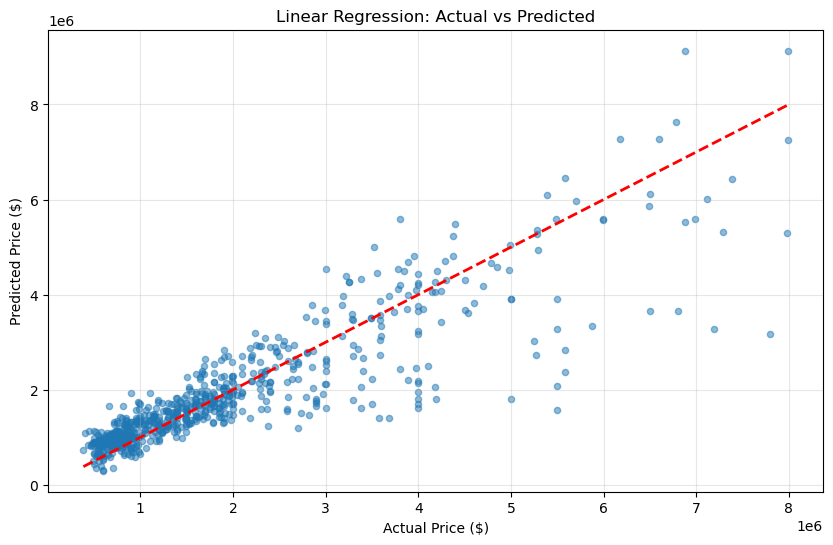


✅ Chart saved to outputs/figures/03_lr_predictions.png


In [ ]:
# Fix Yes/No columns in X BEFORE splitting
yes_no_cols = ['Fireplace', 'Waterfront', 'Pool', 'Garden', 'Balcony']
X[yes_no_cols] = X[yes_no_cols].replace({'Yes': 1, 'No': 0})

# Redo the train/test split with clean data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print(f"✅ Linear Regression trained!")

# Make predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Calculate metrics
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)
mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

# Cross-validation
cv_scores_lr = cross_val_score(lr_model, X, y, cv=5, scoring='r2')

print(f"\n📊 LINEAR REGRESSION RESULTS:")
print(f"Training R²: {train_r2_lr:.4f}")
print(f"Testing R²:  {test_r2_lr:.4f}")
print(f"MAE:         ${mae_lr:,.0f}")
print(f"RMSE:        ${rmse_lr:,.0f}")
print(f"CV R² (mean ± std): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

# Visualize predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_lr, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(alpha=0.3)
plt.savefig('../outputs/figures/03_lr_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart saved to outputs/figures/03_lr_predictions.png")

⁠ html
<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🌲 Step 5 — Random Forest Model</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Train ensemble random forest model for better predictions</p>
</div>


✅ Random Forest trained!

📊 RANDOM FOREST RESULTS:
Training R²: 0.9815
Testing R²:  0.8705
MAE:         $297,602
RMSE:        $529,809
CV R² (mean ± std): 0.8316 ± 0.0398


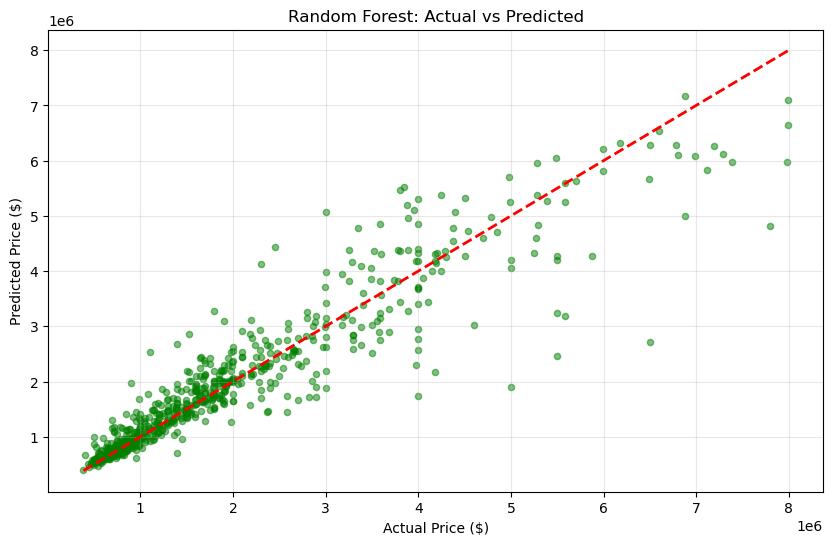


✅ Chart saved to outputs/figures/03_rf_predictions.png


In [ ]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print(f"✅ Random Forest trained!")

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate metrics
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print(f"\n📊 RANDOM FOREST RESULTS:")
print(f"Training R²: {train_r2_rf:.4f}")
print(f"Testing R²:  {test_r2_rf:.4f}")
print(f"MAE:         ${mae_rf:,.0f}")
print(f"RMSE:        ${rmse_rf:,.0f}")
print(f"CV R² (mean ± std): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

# Visualize predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, s=20, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Random Forest: Actual vs Predicted')
plt.grid(alpha=0.3)
plt.savefig('../outputs/figures/03_rf_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart saved to outputs/figures/03_rf_predictions.png")


html
<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">⚖️ Step 6 — Model Comparison</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Compare Linear Regression vs Random Forest performance</p>
</div>



📊 MODEL COMPARISON:
      Metric  Linear Regression  Random Forest
 Training R²           0.783907       0.981510
  Testing R²           0.773835       0.870491
     MAE ($)      433069.811535  297602.051223
    RMSE ($)      700136.083383  529809.293857
CV R² (mean)           0.727534       0.831569

🏆 WINNER: Random Forest
Testing R²: 0.8705
This model explains 87.0% of price variation!


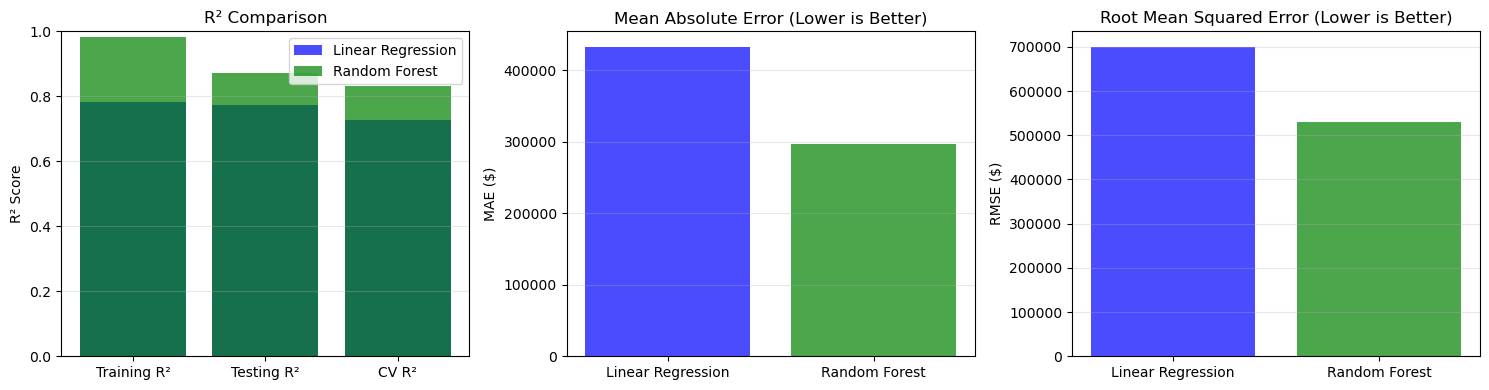


✅ Comparison chart saved to outputs/figures/03_model_comparison.png


In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['Training R²', 'Testing R²', 'MAE ($)', 'RMSE ($)', 'CV R² (mean)'],
    'Linear Regression': [train_r2_lr, test_r2_lr, mae_lr, rmse_lr, cv_scores_lr.mean()],
    'Random Forest': [train_r2_rf, test_r2_rf, mae_rf, rmse_rf, cv_scores_rf.mean()]
})

print(f"\n📊 MODEL COMPARISON:")
print(comparison.to_string(index=False))

# Determine winner
if test_r2_rf > test_r2_lr:
    winner = "Random Forest"
    winner_r2 = test_r2_rf
else:
    winner = "Linear Regression"
    winner_r2 = test_r2_lr

print(f"\n🏆 WINNER: {winner}")
print(f"Testing R²: {winner_r2:.4f}")
print(f"This model explains {winner_r2*100:.1f}% of price variation!")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R² Comparison
metrics = ['Training R²', 'Testing R²', 'CV R²']
lr_vals = [train_r2_lr, test_r2_lr, cv_scores_lr.mean()]
rf_vals = [train_r2_rf, test_r2_rf, cv_scores_rf.mean()]

axes[0].bar(metrics, lr_vals, alpha=0.7, label='Linear Regression', color='blue')
axes[0].bar(metrics, rf_vals, alpha=0.7, label='Random Forest', color='green')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Comparison')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(alpha=0.3, axis='y')

# MAE Comparison
axes[1].bar(['Linear Regression', 'Random Forest'], [mae_lr, mae_rf], color=['blue', 'green'], alpha=0.7)
axes[1].set_ylabel('MAE ($)')
axes[1].set_title('Mean Absolute Error (Lower is Better)')
axes[1].grid(alpha=0.3, axis='y')

# RMSE Comparison
axes[2].bar(['Linear Regression', 'Random Forest'], [rmse_lr, rmse_rf], color=['blue', 'green'], alpha=0.7)
axes[2].set_ylabel('RMSE ($)')
axes[2].set_title('Root Mean Squared Error (Lower is Better)')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/figures/03_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Comparison chart saved to outputs/figures/03_model_comparison.png")


html
<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🔑 Step 7 — Feature Importance Analysis</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Which features matter most for predicting prices?</p>
</div>



🔑 TOP 10 MOST IMPORTANT FEATURES:
                 Feature  Importance
          Square Footage    0.775945
               Longitude    0.112142
                Latitude    0.037046
                 Acreage    0.028721
                Bedrooms    0.011851
               Bathrooms    0.011746
           name_Downtown    0.004140
               Fireplace    0.003197
        name_Shaughnessy    0.001744
name_Renfrew-Collingwood    0.001673


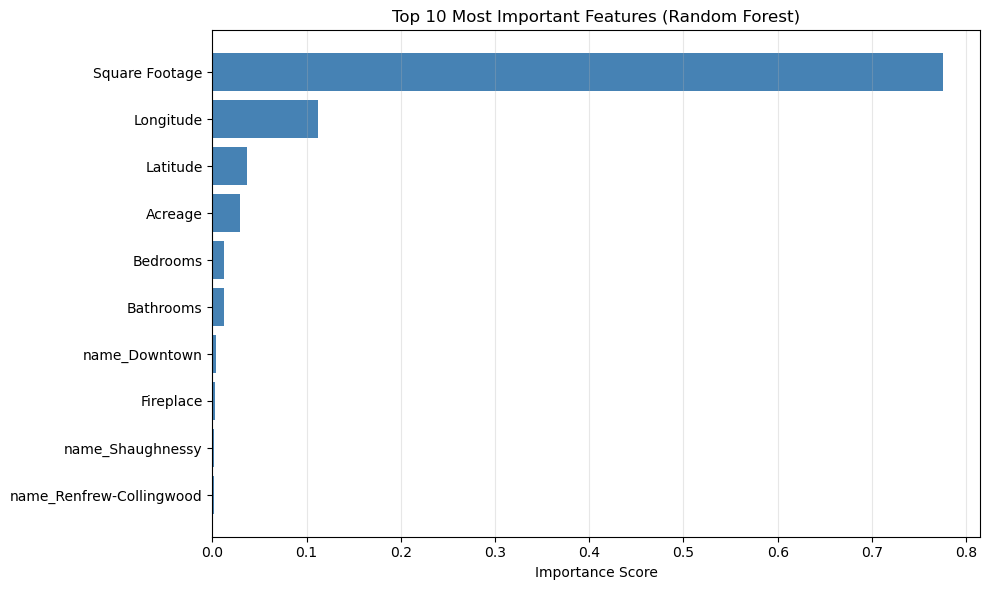


✅ Feature importance chart saved to outputs/figures/03_feature_importance.png


In [ ]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n🔑 TOP 10 MOST IMPORTANT FEATURES:")
print(feature_importance.head(10).to_string(index=False))

# Visualize top 10
plt.figure(figsize=(10, 6))
top_10 = feature_importance.head(10)
plt.barh(top_10['Feature'], top_10['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../outputs/figures/03_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Feature importance chart saved to outputs/figures/03_feature_importance.png")

# ← ADD THIS LINE:
feature_importance_rf = feature_importance.rename(columns={'Feature': 'feature', 'Importance': 'importance'})

html
<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">💾 Step 8 — Save Models</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Save trained models for deployment</p>
</div>


In [ ]:
import pickle

import os
os.makedirs('../outputs/models', exist_ok=True)
print("✅ Folder created!")

# Save models
with open('../outputs/models/linear_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('../outputs/models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print(f"✅ Models saved!")
print(f"  - linear_regression_model.pkl")
print(f"  - random_forest_model.pkl")


✅ Folder created!
✅ Models saved!
  - linear_regression_model.pkl
  - random_forest_model.pkl


In [ ]:
from IPython.display import display, HTML

# Get top 3 features
top3 = feature_importance_rf.head(3)
f1_name = top3.iloc[0]['feature']; f1_imp = top3.iloc[0]['importance']*100
f2_name = top3.iloc[1]['feature']; f2_imp = top3.iloc[1]['importance']*100
f3_name = top3.iloc[2]['feature']; f3_imp = top3.iloc[2]['importance']*100

# Get top 3 neighbourhoods
neigh_cols = [(col.replace('name_',''), feature_importance_rf[feature_importance_rf['feature']==col]['importance'].values[0]) for col in feature_importance_rf['feature'] if col.startswith('name_')]
neigh_sorted = sorted(neigh_cols, key=lambda x: x[1], reverse=True)[:3]

# Winners
r2_winner = "Random Forest" if test_r2_rf > test_r2_lr else "Linear Regression"
mae_winner = "Random Forest" if mae_rf < mae_lr else "Linear Regression"
rmse_winner = "Random Forest" if rmse_rf < rmse_lr else "Linear Regression"
cv_winner = "Random Forest" if cv_scores_rf.mean() > cv_scores_lr.mean() else "Linear Regression"

html = (
    '<div style="background-color:#1a1a2e; padding:20px; border-radius:10px;">'
    '<h3 style="color:#00d4ff;">✅ NOTEBOOK 03 COMPLETE!</h3>'
    '<h4 style="color:#00d4ff; margin-top:20px;">🏆 Model Performance</h4>'
    '<table style="color:#a8a8b3; width:100%; margin-top:10px;">'
    '<tr style="border-bottom:1px solid #444;"><td><b>Metric</b></td><td><b>Linear Regression</b></td><td><b>Random Forest</b></td><td><b>Winner</b></td></tr>'
    f'<tr style="border-bottom:1px solid #444;"><td>Testing R²</td><td>{test_r2_lr:.4f}</td><td>{test_r2_rf:.4f}</td><td>🏆 {r2_winner}</td></tr>'
    f'<tr style="border-bottom:1px solid #444;"><td>MAE ($)</td><td>${mae_lr:,.0f}</td><td>${mae_rf:,.0f}</td><td>🏆 {mae_winner}</td></tr>'
    f'<tr style="border-bottom:1px solid #444;"><td>RMSE ($)</td><td>${rmse_lr:,.0f}</td><td>${rmse_rf:,.0f}</td><td>🏆 {rmse_winner}</td></tr>'
    f'<tr><td>CV R²</td><td>{cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}</td><td>{cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}</td><td>🏆 {cv_winner}</td></tr>'
    '</table>'
    '<h4 style="color:#00d4ff; margin-top:20px;">🔑 Top Features (Random Forest)</h4>'
    '<ul style="color:#a8a8b3; line-height:2;">'
    f'<li>🥇 <b>{f1_name}</b> — {f1_imp:.1f}% of importance</li>'
    f'<li>🥈 <b>{f2_name}</b> — {f2_imp:.1f}% of importance</li>'
    f'<li>🥉 <b>{f3_name}</b> — {f3_imp:.1f}% of importance</li>'
    '</ul>'
    '<h4 style="color:#00d4ff; margin-top:20px;">🏙️ Top Neighbourhoods by Price Impact</h4>'
    '<ul style="color:#a8a8b3; line-height:2;">'
    f'<li>🏠 <b>{neigh_sorted[0][0]}</b> — highest price premium</li>'
    f'<li>🏠 <b>{neigh_sorted[1][0]}</b></li>'
    f'<li>🏠 <b>{neigh_sorted[2][0]}</b></li>'
    '</ul>'
    '<h4 style="color:#00d4ff; margin-top:20px;">📁 Files Created</h4>'
    '<ul style="color:#a8a8b3;">'
    '<li>📊 03_lr_predictions.png — Linear Regression actual vs predicted</li>'
    '<li>📊 03_rf_predictions.png — Random Forest actual vs predicted</li>'
    '<li>📊 03_model_comparison.png — Side-by-side model comparison</li>'
    '<li>📊 03_feature_importance.png — Feature importance rankings</li>'
    '<li>💾 linear_regression_model.pkl — Saved LR model</li>'
    '<li>💾 random_forest_model.pkl — Saved RF model</li>'
    '</ul>'
    '</div>'
)

display(HTML(html))

Metric,Linear Regression,Random Forest,Winner
Testing R²,0.7738,0.8705,🏆 Random Forest
MAE ($),"$433,070","$297,602",🏆 Random Forest
RMSE ($),"$700,136","$529,809",🏆 Random Forest
CV R²,0.7275 ± 0.0343,0.8316 ± 0.0398,🏆 Random Forest
